In [3]:
from diffusers import DiffusionPipeline  # noqa: E402
import torch
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import gc
from torchvision import transforms

tmpdir = '/home/qzhao9/code/sd_ft_lora/diffuusers/diffusers/examples/text_to_image/sd-kvasir-model-lora/checkpoint-5000'

pipe = DiffusionPipeline.from_pretrained(
"CompVis/stable-diffusion-v1-4", safety_checker=None, device_map='cuda'
)
pipe.load_lora_weights(tmpdir)
print('Model Loaded to ', pipe.device)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/n

Model Loaded to  cuda:0


In [22]:
import numpy as np

eval_cfg = {
    'num_inference_steps': 20,
    'guidance_scale': 7.5,
    'height': 512,
    'width': 512,
    'generator': torch.Generator(device='cuda').manual_seed(56),
    'negative_prompt':'Do NOT generate text, timestamp,or box at any corner of the image.'
    }

eval_prompts = [
    "A detailed endoscopic image showing inflamed mucosa with ulcerations and erythema, indicative of active ulcerative colitis.",
    "An endoscopic view of the colon revealing multiple polyps of varying sizes, some with a sessile appearance, requiring biopsy for histopathological evaluation.",
    "A high-resolution endoscopic image capturing a bleeding gastric ulcer with visible vessel, surrounded by edematous and erythematous tissue." 
    "endoscopic image of the colon with realistic mucosal texture and lighting",
    "endoscopic view of the colonic lumen with natural illumination and shadows",
    "wide-angle endoscopic view of colon interior"  
]

def generate(pipe, prompts, eval_cfg, numbers=1, save_path=None):
    # pipe.unet.eval()
    images = []
    for _ in range(numbers):
        for i, prompt in enumerate(prompts):
            result = pipe(prompt, **eval_cfg ).images
            image = result[0]
            images.append(image)
    grid = vutils.make_grid([transforms.ToTensor()(img) for img in images], nrow=3) #numbers
    plt.figure(figsize=(5*3,5*3)) #(5*numbers,5*len(prompts)
    plt.axis('off')
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    if save_path:
        plt.savefig(save_path, dpi=600)
    plt.show()

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

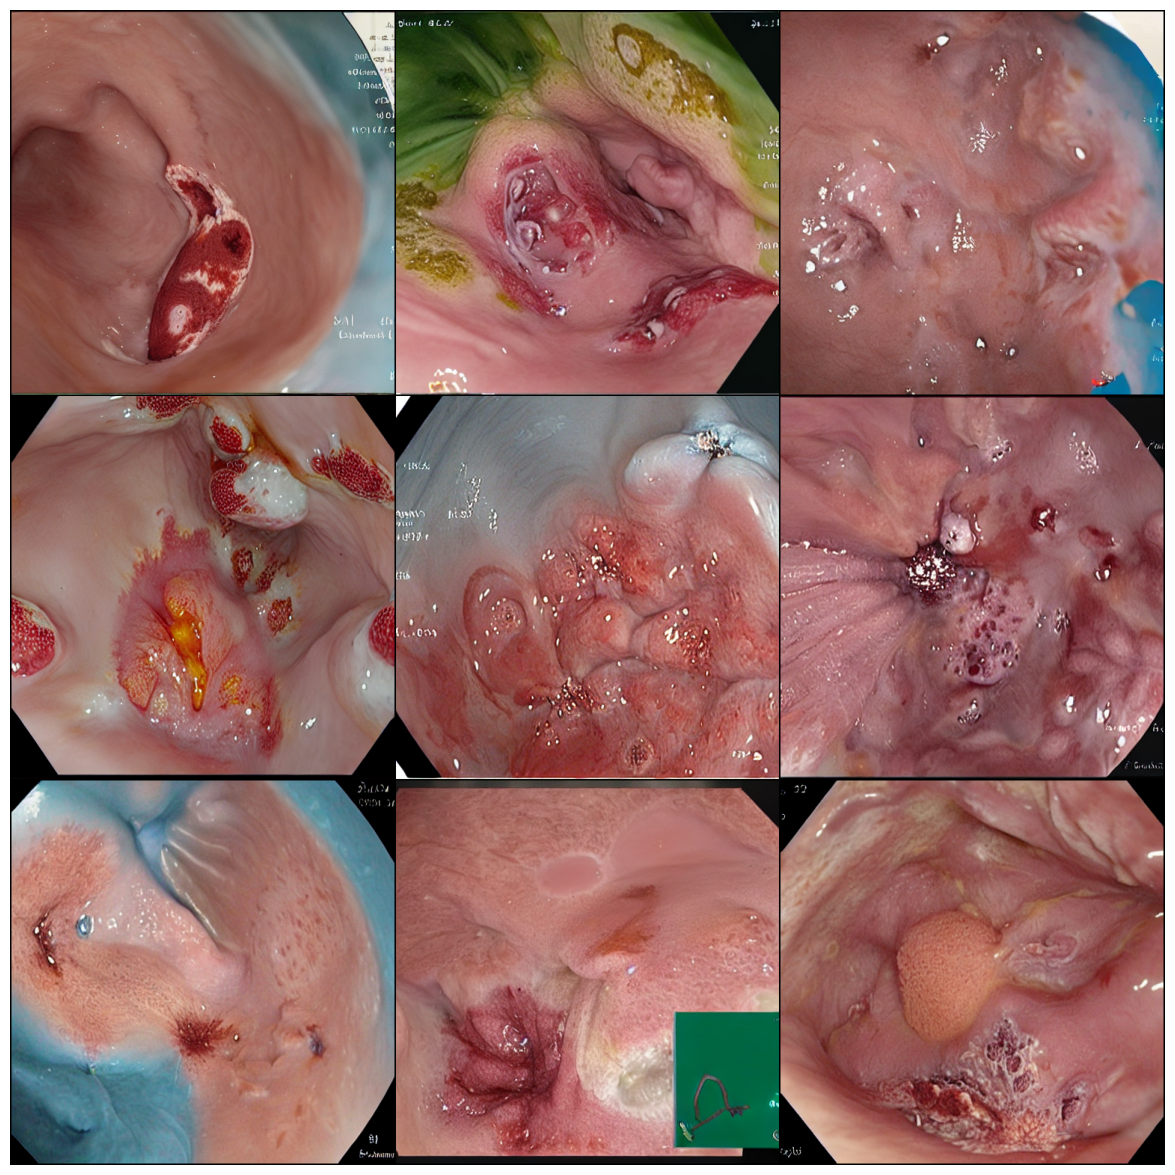

In [25]:
generate(pipe, 
         ['Generate images depicting an uncommon presentation of inflammatory bowel disease characterized by patchy ulcerations and abnormal mucosal texture.',
         ], 
         eval_cfg,
         9,'/home/qzhao9/code/scenario3.png')